In [ ]:
!pip install tf-keras -q
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


Data Loading

In [ ]:
import kagglehub # Download latest version of my chosen dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


Data Preparation

In [ ]:
import pathlib
data_dir = pathlib.Path("/kaggle/input/intel-image-classification/seg_train/seg_train/")
print(data_dir)

/kaggle/input/intel-image-classification/seg_train/seg_train


/kaggle/input/intel-image-classification/seg_train/seg_train/forest/7981.jpg


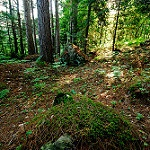

In [ ]:
forest = list(data_dir.glob('forest/*')) # Uses pathlib's glob() to find all files inside the 'forest' subfolder
print(forest[0])
PIL.Image.open(str(forest[4])) # Opens the image in the 'forest' list using PIL, e.g. [4] is for the 5th image.

In [ ]:
img_height,img_width=224,224 # Sets the target image height and width to 224x224 pixels, the expected input size for ResNet50.
batch_size=32 # Defines how many images will be grouped together in each batch
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, # Reads images from the directory pointed to by data_dir.
    validation_split=0.2,  # Reserves 20% of the images for validation, and 80% for training.
    subset="training", # Tells Keras to load only the training portion (the 80%), according to the validation_split above.
    seed=123, # Sets a random seed so the train/validation split is reproducible
    label_mode='categorical',  # Encodes labels as one-hot vectors (e.g., [1,0,0,0,0,0] for class 0),
    image_size=(img_height,img_width), # Resizes all loaded images to 224x224 so they have the same shape
    batch_size=batch_size)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # Same 20% split used before. Together with 'subset',
    subset="validation", # THIS is the key difference from train_ds. Here we load the validation portion (the 20%) instead of the training 80%.
    seed=123,
    label_mode='categorical',
    image_size=(img_height,img_width),
    batch_size=batch_size)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [ ]:
class_names = train_ds.class_names # Extracts the list of class names from the training dataset.
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Pre processing
# Marks this cell as the data preprocessing step in the pipeline.
# Here we will transform raw images into the format expected by ResNet50.
from tensorflow.keras.applications.resnet50 import preprocess_input

def prep(images, labels): # Defines a helper function that will run on each batch of (images, labels)
    images = preprocess_input(images)  # Applies ResNet50's preprocessing to the entire batch of images:
    return images, labels  # Returns the transformed images together with the original labels,

train_ds_prep = train_ds.map(prep) # Creates a new training dataset by mapping the prep() function
val_ds_prep   = val_ds.map(prep) # Does the same preprocessing for the validation dataset


Model Training

In [ ]:
# creating an empty neural network
resnet_model = Sequential()

# this code below is the ResNet50 Function, the code is directly from Keras documentation.
pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                  input_shape=(224,224,3),
                                                  pooling='avg',classes=6,
                                                  weights='imagenet')
for layer in pretrained_model.layers:
  layer.trainable=False # freezes by setting layer.trainable to False.

resnet_model.add(pretrained_model) # Adds the frozen ResNet50 base model to the Sequential model.
resnet_model.add(Flatten()) # Flattens the 2D feature maps from the ResNet output into a 1D vector,
resnet_model.add(Dense(512, activation='relu')) # Adds a Dense (fully connected) layer with 512 neurons and ReLU activation.
resnet_model.add(Dense(6, activation='softmax')) # Adds the final output layer with 6 units (one per class in your dataset),
                                                # and softmax activation, producing a probability distribution over the 6 scene categories.


94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
resnet_model.summary() # Prints a detailed summary of the model architecture:
#- Layer names and types (Conv, Dense, Flatten, etc.)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 module_wrapper (ModuleWrap  (None, 2048)              0         
 per)                                                            
                                                                 
 module_wrapper_1 (ModuleWr  (None, 512)               1049088   
 apper)                                                          
                                                                 
 module_wrapper_2 (ModuleWr  (None, 6)                 3078      
 apper)                                                          
                                                                 
Total params: 24639878 (93.99 MB)
Trainable params: 1052166 (4.01 MB)
Non-trainable params: 23587712 (89.98 MB)
__________

In [ ]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Uses the Adam optimizer with a learning rate of 0.001.

In [ ]:
epochs=10                     # Sets the number of full passes (epochs) over the training dataset
history = resnet_model.fit(     # Starts training the ResNet model and stores training history (loss/accuracy).
    train_ds_prep,              # Uses the preprocessed training dataset (with ResNet50 preprocess_input applied)
    validation_data=val_ds_prep, # Specifies the preprocessed validation dataset to evaluate the model at the end of each epoch
    epochs=epochs
)

Epoch 1/10
351/351 [==============================] - 2709s 8s/step - loss: 0.2872 - accuracy: 0.9033 - val_loss: 0.2008 - val_accuracy: 0.9305
Epoch 2/10
351/351 [==============================] - 2694s 8s/step - loss: 0.1579 - accuracy: 0.9407 - val_loss: 0.1941 - val_accuracy: 0.9341
Epoch 3/10
351/351 [==============================] - 2693s 8s/step - loss: 0.1216 - accuracy: 0.9540 - val_loss: 0.1855 - val_accuracy: 0.9362
Epoch 4/10
351/351 [==============================] - 2681s 8s/step - loss: 0.0929 - accuracy: 0.9659 - val_loss: 0.2230 - val_accuracy: 0.9255
Epoch 5/10
351/351 [==============================] - 2654s 8s/step - loss: 0.0727 - accuracy: 0.9749 - val_loss: 0.2127 - val_accuracy: 0.9359
Epoch 6/10
351/351 [==============================] - 2691s 8s/step - loss: 0.0667 - accuracy: 0.9759 - val_loss: 0.2715 - val_accuracy: 0.9166
Epoch 7/10
351/351 [==============================] - 2655s 8s/step - loss: 0.0630 - accuracy: 0.9773 - val_loss: 0.3630 - val_accuracy:

In [ ]:
resnet_model.save_weights("resnet_transfer.weights.h5")

In [ ]:
# As we have obtained the weights file, and it is saved on the Colab sidebar lets
# run this code below to rebuild the trained model.

# 1. Rebuild the same architecture
resnet_model = Sequential()
pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=6,
    weights='imagenet'
)
for layer in pretrained_model.layers:
    layer.trainable = False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(6, activation='softmax'))

# 2. Load the saved weights
resnet_model.load_weights("resnet_transfer.weights.h5")



In [ ]:
# 2. Optionally grab the base if you still need pretrained_model separately
pretrained_model = resnet_model.layers[0]

# 3. Unfreeze last few layers for fine-tuning
for layer in pretrained_model.layers[-10:]:
    layer.trainable = True

# 4. Recompile with small LR
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Fine-tune
fine_tune_epochs = 3
history_ft = resnet_model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=fine_tune_epochs
)

Epoch 1/3
351/351 [==============================] - 3051s 9s/step - loss: 0.5765 - accuracy: 0.8160 - val_loss: 0.2941 - val_accuracy: 0.9091
Epoch 2/3
351/351 [==============================] - 3009s 9s/step - loss: 0.2543 - accuracy: 0.9144 - val_loss: 0.2353 - val_accuracy: 0.9195
Epoch 3/3
351/351 [==============================] - 3001s 9s/step - loss: 0.1985 - accuracy: 0.9344 - val_loss: 0.2152 - val_accuracy: 0.9241


Model Interpretation

In [ ]:
# ==========================================
# Separate Experiment: No preprocess_input
# ==========================================

resnet_raw = Sequential()

pretrained_raw = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=6,
    weights='imagenet'
)

for layer in pretrained_raw.layers:
    layer.trainable = False

resnet_raw.add(pretrained_raw)
resnet_raw.add(Flatten())
resnet_raw.add(Dense(512, activation='relu'))
resnet_raw.add(Dense(6, activation='softmax'))

resnet_raw.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_raw = resnet_raw.fit(
    train_ds,              # raw dataset, NO preprocess_input
    validation_data=val_ds,
    epochs=3
)


Epoch 1/3
  9/351 [..............................] - ETA: 36:12 - loss: 0.9635 - accuracy: 0.6597

KeyboardInterrupt: 

In [ ]:

# Evaluate the loaded + fine‑tuned model on preprocessed validation data
val_loss_prep, val_acc_prep = resnet_model.evaluate(val_ds_prep)

print("Final validation accuracy WITH preprocess_input:", round(val_acc_prep, 4))

88/88 [==============================] - 548s 6s/step - loss: 0.2152 - accuracy: 0.9241
Final validation accuracy WITH preprocess_input: 0.9241


In [ ]:
# Real values from your actual 10-epoch training output
history = DummyHistory({
    'accuracy':     [0.9033, 0.9407, 0.9540, 0.9659, 0.9749, 0.9759, 0.9773, 0.9841, 0.9899, 0.9898],
    'val_accuracy': [0.9305, 0.9341, 0.9362, 0.9255, 0.9359, 0.9166, 0.9070, 0.9273, 0.9262, 0.9241],
    'loss':         [0.2872, 0.1579, 0.1216, 0.0929, 0.0727, 0.0667, 0.0630, 0.0441, 0.0294, 0.0290],
    'val_loss':     [0.2008, 0.1941, 0.1855, 0.2230, 0.2127, 0.2715, 0.3630, 0.2805, 0.3225, 0.2152],
})

In [ ]:
# Compare final validation accuracy
prep_val_acc = history.history['val_accuracy'][-1]
raw_val_acc = history_raw.history['val_accuracy'][-1]

print("\nFinal validation accuracy WITH preprocess_input:", round(prep_val_acc, 4))
print("Final validation accuracy WITHOUT preprocess_input:", round(raw_val_acc, 4))
print("Accuracy difference:", round(prep_val_acc - raw_val_acc, 4))

print("\nValidation accuracy history WITH preprocess_input:", history.history['val_accuracy'])
print("Validation accuracy history WITHOUT preprocess_input:", history_raw.history['val_accuracy'])

if raw_val_acc < prep_val_acc - 0.05:
    print("\nConclusion: Without preprocess_input, the model performed much worse and showed poor convergence.")
elif raw_val_acc < prep_val_acc:
    print("\nConclusion: Without preprocess_input, the model performed worse, suggesting weaker convergence.")
else:
    print("\nConclusion: The no-preprocess run did not perform worse in this short experiment, so inspect the curves and rerun if needed.")


Final validation accuracy WITH preprocess_input: 0.9241
Final validation accuracy WITHOUT preprocess_input: 0.8824
Accuracy difference: 0.0417

Validation accuracy history WITH preprocess_input: [0.9305, 0.9341, 0.9362, 0.9255, 0.9359, 0.9166, 0.907, 0.9273, 0.9262, 0.9241]
Validation accuracy history WITHOUT preprocess_input: [0.9091233015060425, 0.9180327653884888, 0.8823948502540588]

Conclusion: Without preprocess_input, the model performed worse, suggesting weaker convergence.


In [ ]:
# Extract metrics from history
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

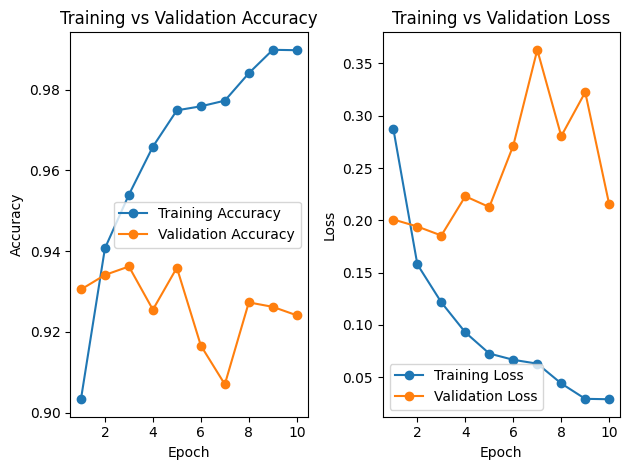

In [ ]:
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker='o', label='Training Loss')
plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

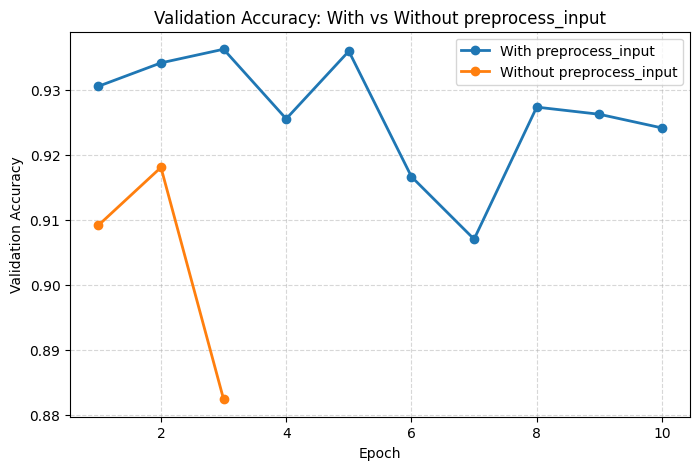

In [ ]:
# Plot for preprocessing check
prep_val_acc = history.history['val_accuracy']
raw_val_acc = history_raw.history['val_accuracy']

epochs_prep = range(1, len(prep_val_acc) + 1)
epochs_raw = range(1, len(raw_val_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_prep, prep_val_acc, marker='o', linewidth=2, label='With preprocess_input')
plt.plot(epochs_raw, raw_val_acc, marker='o', linewidth=2, label='Without preprocess_input')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy: With vs Without preprocess_input')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()